In [1]:
import sys
import os
from pathlib import Path
# Resolve the absolute path of the project root
project_root = Path(os.getcwd()).resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
import balltracking.balltrack as blt
from functools import partial
from time import time
from optimization import inputs_ISSI1 as inputs
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np

len(datafiles)= 361


In [23]:
datafiles = [sorted(Path(os.environ['DATA'], 
f'ISSI/Matthias/SSD_25x8Mm_16_pdmp_1_ISSI_Flows/rebinned/correlations/drift_{dd:02d}').glob('*.fits')) for dd in range(10)]

# Rearange the drift directories, exclude the 0-velocity to have symmetry in the plot between top and bottom row.
rdatafiles =  datafiles[::-1][0:5]
datafiles2 = datafiles[0:5].copy()
print(len(datafiles2))
for r in rdatafiles:
    datafiles2.append(r)
print(len(rdatafiles), len(datafiles2))

vx_rates = [-0.05, -0.04, -0.03, -0.02, -0.01, 0.05, 0.04, 0.03, 0.02, 0.01]



5
5 10


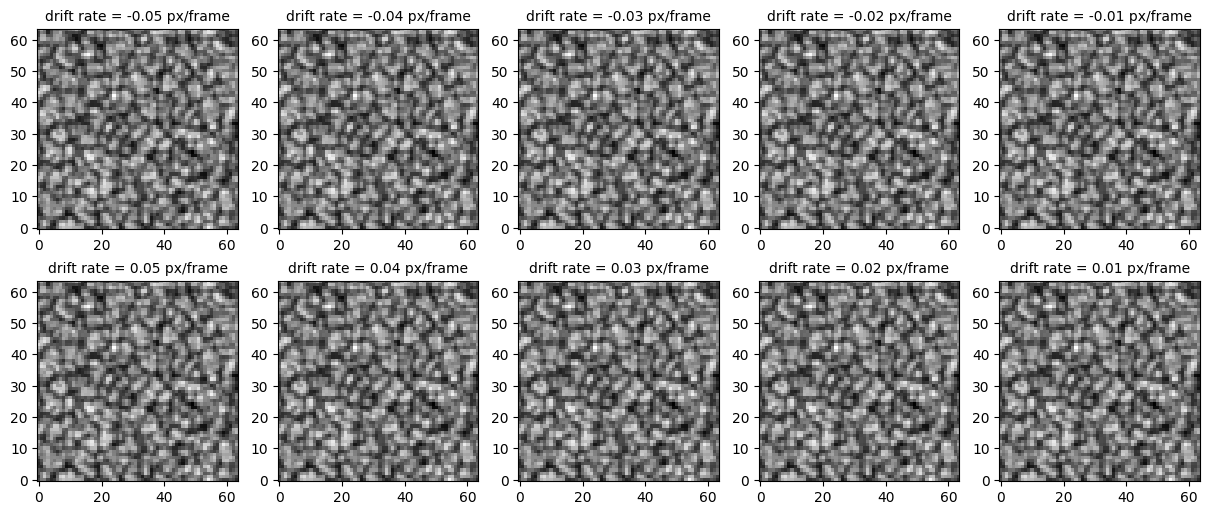

In [24]:
dd = 0
idx = 0
im = fits.getdata(datafiles[0][0])
vmin = np.percentile(im, 0.1)
vmax = np.percentile(im, 99.9)

nrows, ncols = (2, 5)

plt.close('all')
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15,6))

for n, dd in enumerate(datafiles[0:10]):

    ax = axs[n//ncols, n%ncols]
    im = fits.getdata(dd[0])
    ax.imshow(im, origin='lower', cmap='gray')
    ax.set_title(f'drift rate = {vx_rates[n]:0.2f} px/frame', fontsize=10)


In [25]:

outputdir = Path(os.environ['DATA'], 
f'ISSI/Matthias/SSD_25x8Mm_16_pdmp_1_ISSI_Flows/rebinned/correlations/figures')


plt.close('all')
for idx in range(341):
    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15,6))

    for n, dd in enumerate(datafiles2):        
        ax = axs[n//ncols, n%ncols]
        
        im = fits.getdata(dd[idx])
        ax.imshow(im, origin='lower', cmap='gray')
        ax.set_title(f'#{idx} drift = {vx_rates[n]:0.2f} px/frame', fontsize=10)
        
    plt.savefig(outputdir / f'drifts_{idx}.png')
    plt.close(fig)

In [26]:
import ffmpeg

# Define input pattern and output path
input_pattern = str(outputdir / 'drifts_%d.png')
output_movie = str(outputdir / 'drifts_movie.mp4')

try:
    # Generate mp4 movie from the series of PNG files at 30 fps with h264 codec
    (   ffmpeg
        .input(input_pattern, framerate=30)
        .output(output_movie, vcodec='libx264', pix_fmt='yuv420p')
        .overwrite_output()
        .run(capture_stdout=True, capture_stderr=True)
    )
    print(f"Successfully generated movie at: {output_movie}")
except ffmpeg.Error as e:
    print("FFmpeg Error:")
    print(e.stderr.decode("utf8"))


Successfully generated movie at: /Users/rattie/data/ISSI/Matthias/SSD_25x8Mm_16_pdmp_1_ISSI_Flows/rebinned/correlations/figures/drifts_movie.mp4
